In [2]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.metrics import f1_score
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report, mean_absolute_error, r2_score

In [3]:

df = pd.read_csv('Health_Resource_Allocation_Dataset.csv')
print("first five rows of the dataset")
print(df.head())
print('-'*50)



first five rows of the dataset
  District    Region Population  Health_Facilities Doctors  Nurses  \
0    Jinja  Northern     464002                 11      23     568   
1   Masaka  Northern      89317                 16     116     448   
2  Kampala   Central     284083                 79      20     426   
3     Gulu   Western     489499                 23     143     140   
4   Kabale  Northern     440487                 17     145      84   

  Hospital_Beds  Disease_Cases  Medicine_Stock  Emergency_Visits  \
0           116          24465            77.0              1050   
1            91          16272            45.0              9128   
2            70          14988            42.0              9220   
3           604          20716            75.0              3061   
4           597           4406            79.0              3474   

  Budget_Million_UGX Resource_Need_Level  
0               7652              Medium  
1               3677              Medium  
2         

In [4]:
print("Information about the dataset")
df.info()
print('-'*50)
print("Statistical summary of the dataset")
df.describe()

Information about the dataset
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   District             1500 non-null   object 
 1   Region               1500 non-null   object 
 2   Population           1500 non-null   object 
 3   Health_Facilities    1500 non-null   int64  
 4   Doctors              1499 non-null   object 
 5   Nurses               1500 non-null   int64  
 6   Hospital_Beds        1500 non-null   object 
 7   Disease_Cases        1500 non-null   int64  
 8   Medicine_Stock       1499 non-null   float64
 9   Emergency_Visits     1500 non-null   int64  
 10  Budget_Million_UGX   1499 non-null   object 
 11  Resource_Need_Level  1500 non-null   object 
dtypes: float64(1), int64(4), object(7)
memory usage: 140.8+ KB
--------------------------------------------------
Statistical summary of the dataset


,Health_Facilities,Nurses,Disease_Cases,Medicine_Stock,Emergency_Visits
count,1500.000000,1500.000000,1500.000000,1499.000000,1500.000000
mean,41.668000,309.304667,25262.232667,70.130087,5015.640667
std,21.663825,169.039475,14125.409750,17.339569,2912.121972
min,5.000000,20.000000,562.000000,40.000000,102.000000
25%,23.000000,163.000000,13430.750000,56.000000,2439.000000
50%,40.000000,296.500000,24658.000000,70.000000,5040.500000
75%,60.000000,457.250000,37307.750000,85.000000,7621.750000
max,80.000000,600.000000,49960.000000,150.000000,9996.000000


In [5]:
numerical_columns = ['Population', 'Doctors', 'Hospital_Beds', 'Budget_Million_UGX']

for col in numerical_columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')

In [6]:
# Check missing values and % missing per feature
missing_counts = df.isna().sum()
missing_pct = (df.isna().mean() * 100).round(2)

missing_summary = pd.DataFrame({
    'missing_count': missing_counts,
    'missing_%': missing_pct
}).sort_values('missing_%', ascending=False)

print(missing_summary)

                     missing_count  missing_%
Budget_Million_UGX               2       0.13
Doctors                          2       0.13
Population                       1       0.07
Medicine_Stock                   1       0.07
Hospital_Beds                    1       0.07
Health_Facilities                0       0.00
District                         0       0.00
Region                           0       0.00
Disease_Cases                    0       0.00
Nurses                           0       0.00
Emergency_Visits                 0       0.00
Resource_Need_Level              0       0.00


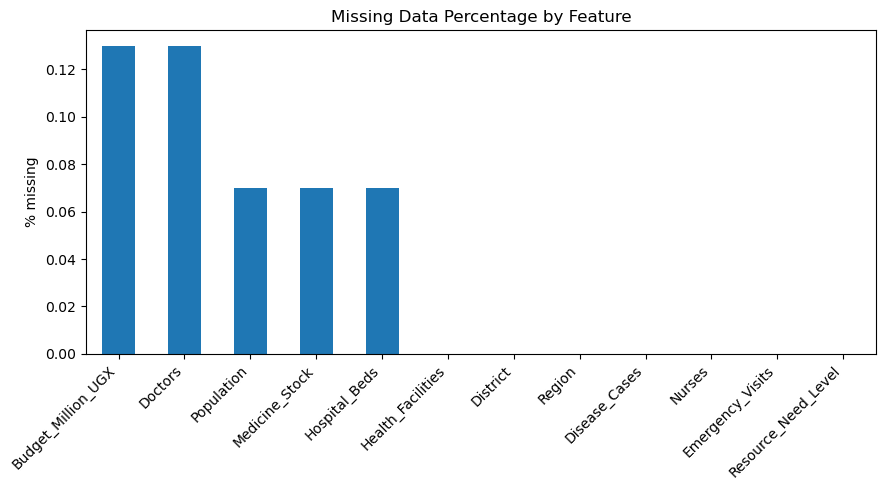

In [7]:
fig, ax = plt.subplots(figsize=(9, 5))
missing_summary['missing_%'].sort_values(ascending=False).plot.bar(ax=ax)
ax.set_title('Missing Data Percentage by Feature')
ax.set_ylabel('% missing')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [8]:
#impute missing values using mean 
cols_to_impute = ['Population', 'Doctors', 'Hospital_Beds', 'Budget_Million_UGX', 'Medicine_Stock']

df_before_impute = df[cols_to_impute].copy()

for col in cols_to_impute:
    if df[col].isna().sum() > 0:
        mean_val = df[col].mean()
        df[col] = df[col].fillna(mean_val)
        print(f"{col}: filled {missing_counts[col]} missing value(s) with mean = {mean_val}")

Population: filled 1 missing value(s) with mean = 477555.2008005337
Doctors: filled 2 missing value(s) with mean = 99.24899866488651
Hospital_Beds: filled 1 missing value(s) with mean = 497.8278852568379
Budget_Million_UGX: filled 2 missing value(s) with mean = 4031.944592790387
Medicine_Stock: filled 1 missing value(s) with mean = 70.130086724483


In [9]:
# Confirm no missing values remain, and that the fill didn't distort the distribution
print("Missing values remaining:\n", df.isna().sum())

print("\nUpdated statistical summary:\n", df[cols_to_impute].describe())



Missing values remaining:
 District               0
Region                 0
Population             0
Health_Facilities      0
Doctors                0
Nurses                 0
Hospital_Beds          0
Disease_Cases          0
Medicine_Stock         0
Emergency_Visits       0
Budget_Million_UGX     0
Resource_Need_Level    0
dtype: int64

Updated statistical summary:
           Population      Doctors  Hospital_Beds  Budget_Million_UGX  \
count    1500.000000  1500.000000    1500.000000         1500.000000   
mean   477555.200801    99.248999     497.827885         4031.944593   
std    246111.222895    56.015771     282.866266         2217.184148   
min     51814.000000    -8.000000      20.000000          201.000000   
25%    262733.000000    49.750000     247.000000         2132.000000   
50%    474082.000000    99.124499     493.000000         3980.000000   
75%    698310.500000   143.250000     739.500000         5926.250000   
max    899988.000000   200.000000    1000.000000     

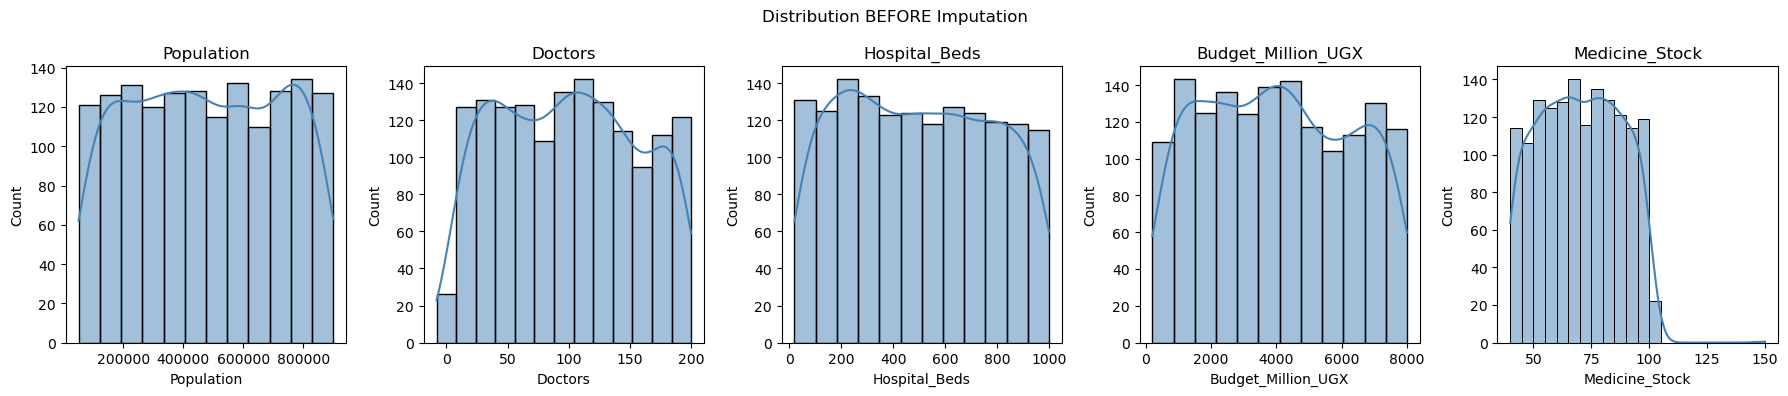

In [10]:
fig, axes = plt.subplots(1, len(cols_to_impute), figsize=(18, 4))
for ax, col in zip(axes, cols_to_impute):
    sns.histplot(df_before_impute[col].dropna(), kde=True, ax=ax, color='steelblue')
    ax.set_title(col)
plt.suptitle('Distribution BEFORE Imputation')
plt.tight_layout()
plt.show()

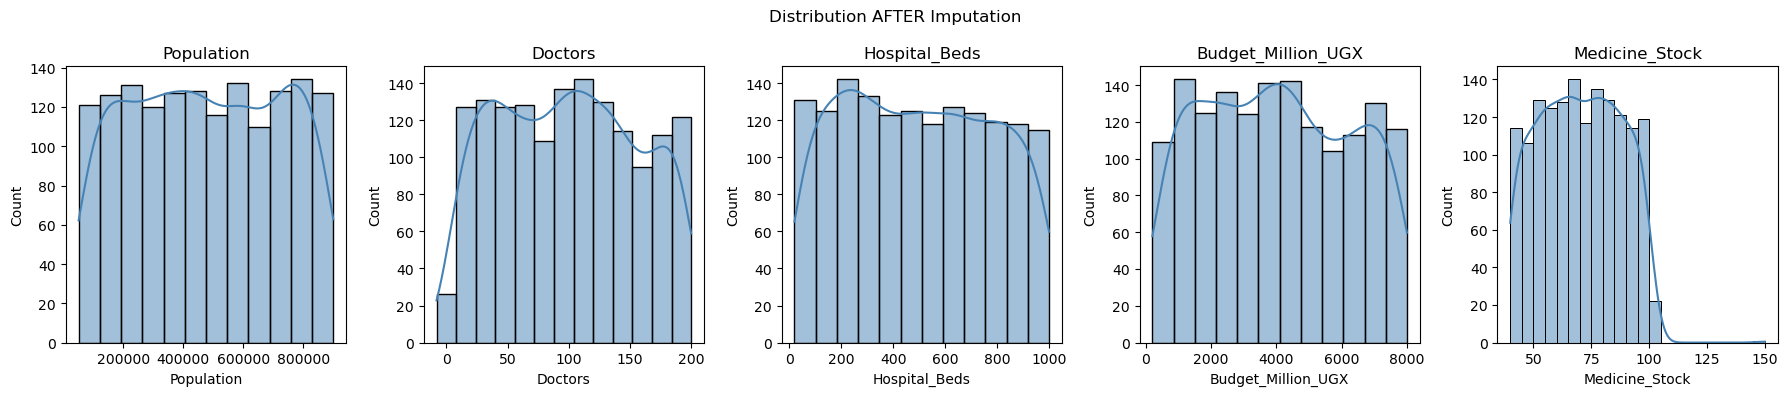

In [11]:
fig, axes = plt.subplots(1, len(cols_to_impute), figsize=(18, 4))
for ax, col in zip(axes, cols_to_impute):
    sns.histplot(df[col], kde=True, ax=ax, color='steelblue')
    ax.set_title(col)
plt.suptitle('Distribution AFTER Imputation')
plt.tight_layout()
plt.show()

C:\Users\olayo\AppData\Local\Temp\ipykernel_43428\941793386.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='District', y='Population', data=df, errorbar=None, palette='viridis')


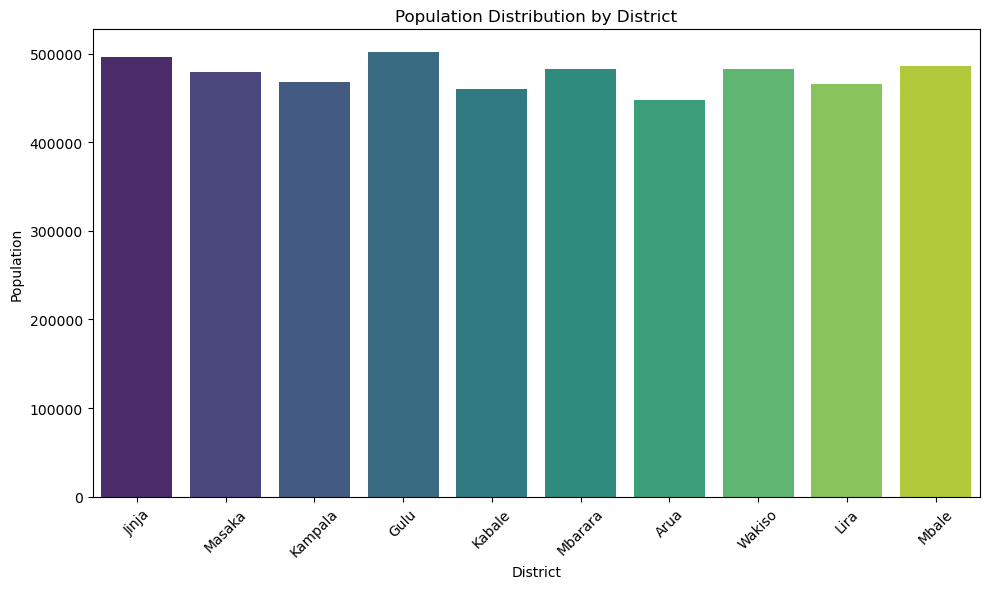

In [12]:
#A barplot for districts against population
plt.figure(figsize=(10, 6))
sns.barplot(x='District', y='Population', data=df, errorbar=None, palette='viridis')
plt.title('Population Distribution by District')
plt.xlabel('District')
plt.ylabel('Population')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


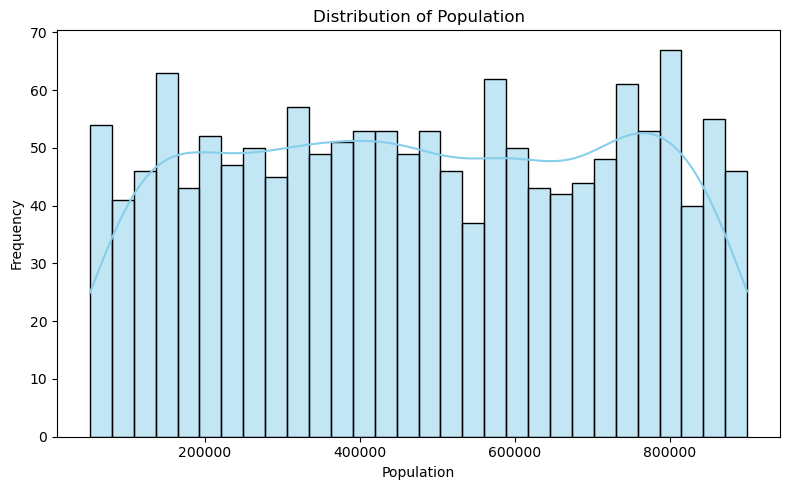

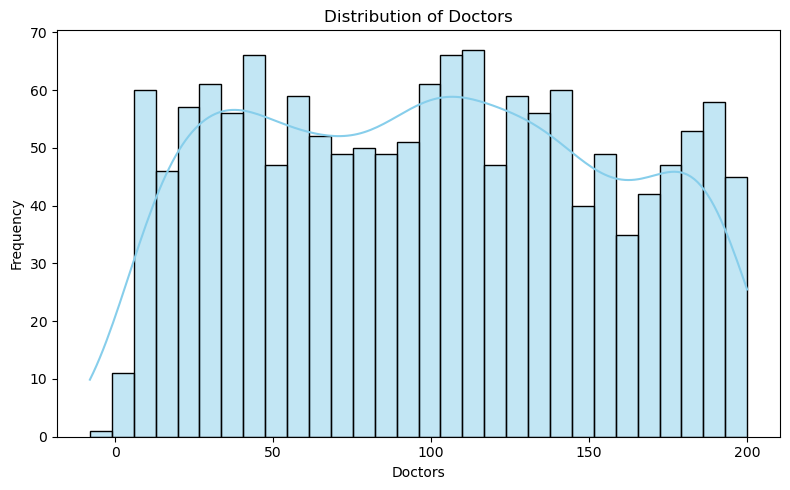

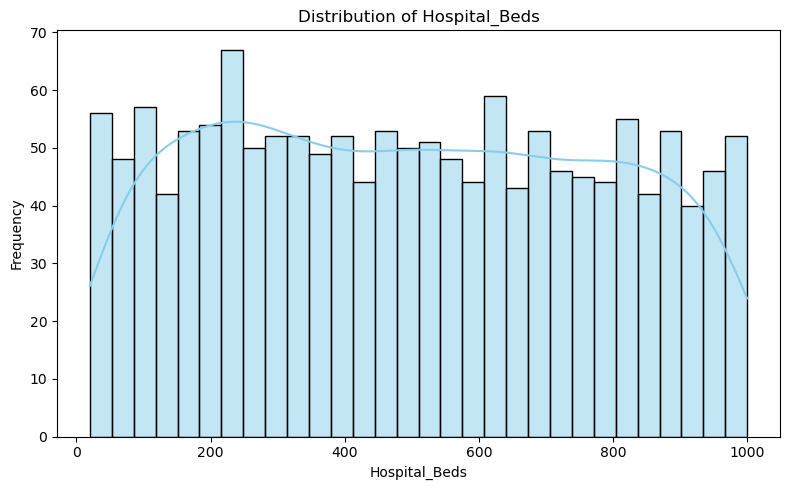

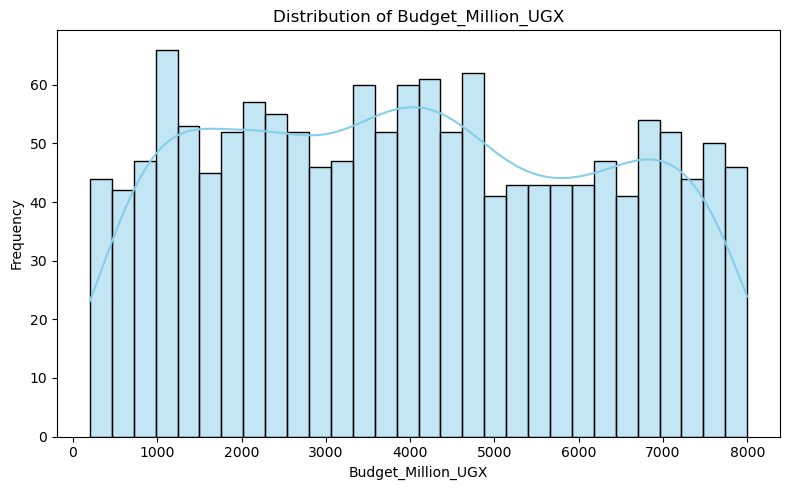

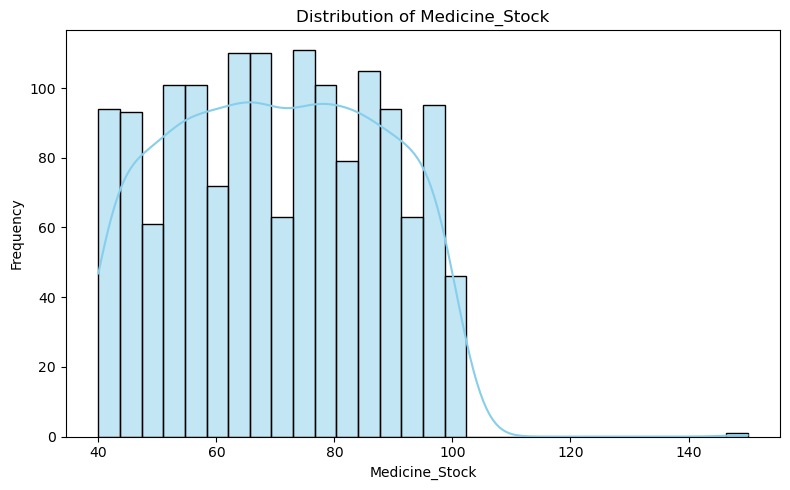

In [13]:
#distribution analysis for doctors, hospital beds, budget, and medicine stock
for col in cols_to_impute:
    plt.figure(figsize=(8, 5))
    sns.histplot(df[col], kde=True, bins=30, color='skyblue')
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()

C:\Users\olayo\AppData\Local\Temp\ipykernel_43428\2074089120.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='District', y=col, data=df, errorbar=None, palette='coolwarm')


<Figure size 1000x600 with 0 Axes>

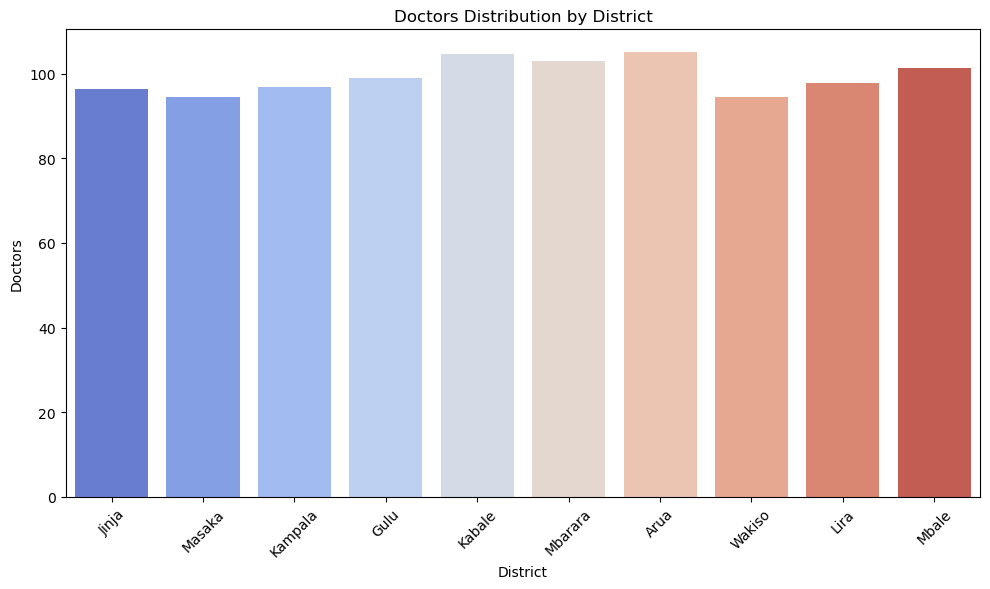

C:\Users\olayo\AppData\Local\Temp\ipykernel_43428\2074089120.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='District', y=col, data=df, errorbar=None, palette='coolwarm')


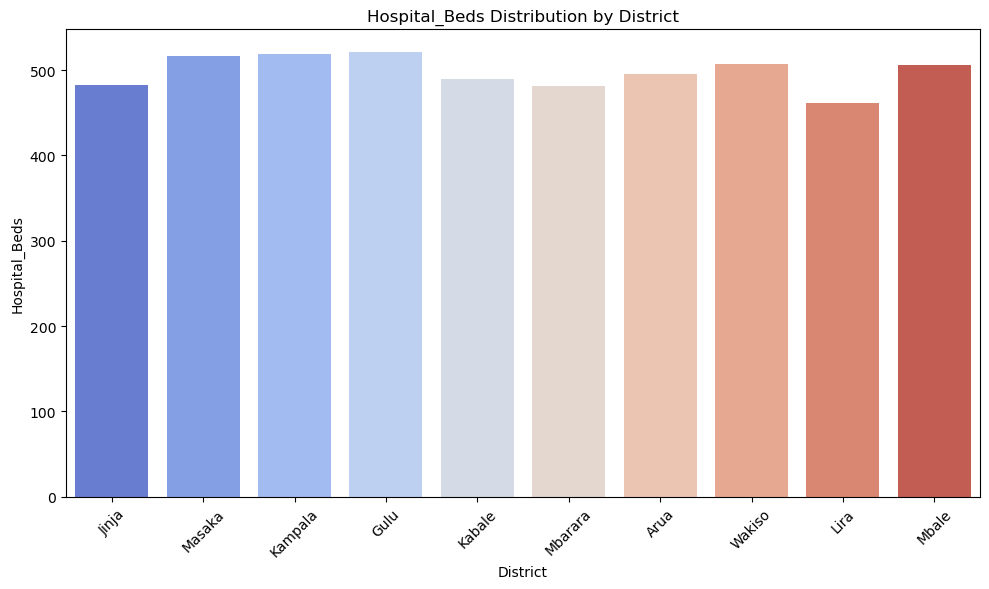

C:\Users\olayo\AppData\Local\Temp\ipykernel_43428\2074089120.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='District', y=col, data=df, errorbar=None, palette='coolwarm')


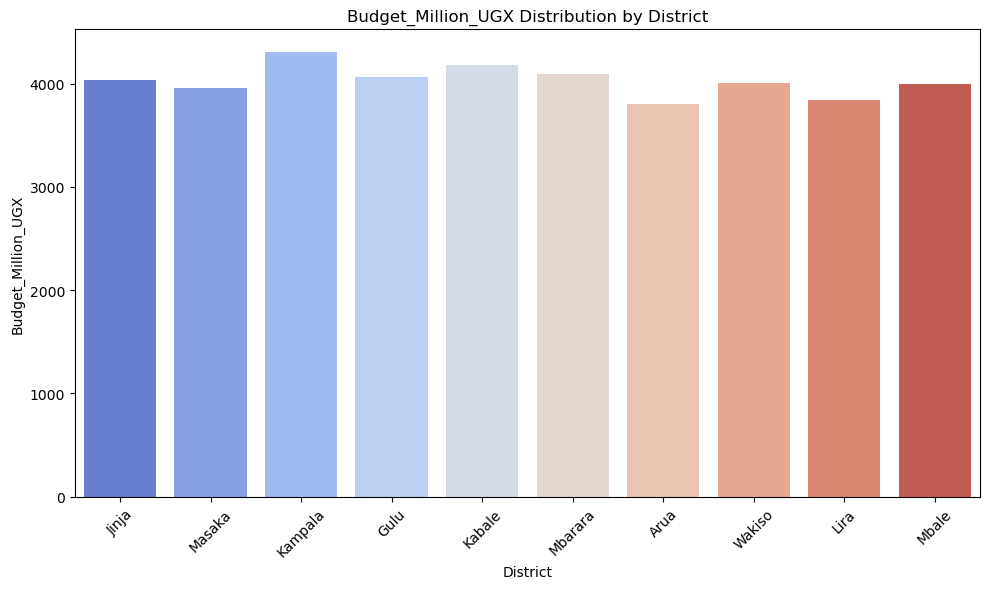

C:\Users\olayo\AppData\Local\Temp\ipykernel_43428\2074089120.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='District', y=col, data=df, errorbar=None, palette='coolwarm')


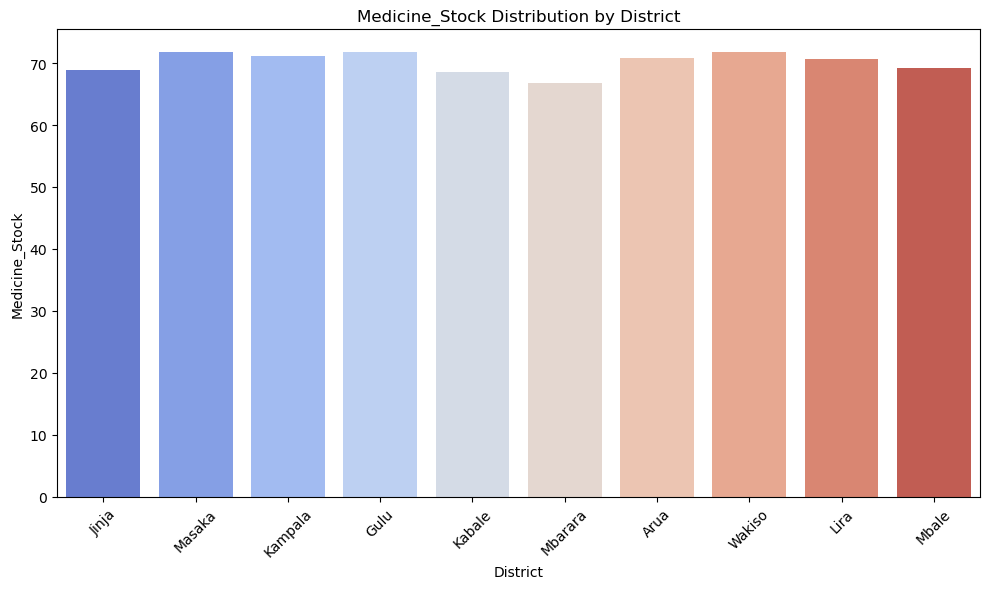

In [14]:
#comparing resource allocation across districts using barplots for doctors, hospital beds, budget, and medicine stock
for col in cols_to_impute:
    plt.figure(figsize=(10, 6))
    #exclude population distribution as it has already been plotted
    if col != 'Population':
        sns.barplot(x='District', y=col, data=df, errorbar=None, palette='coolwarm')
        plt.title(f'{col} Distribution by District')
        plt.xlabel('District')
        plt.ylabel(col)
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

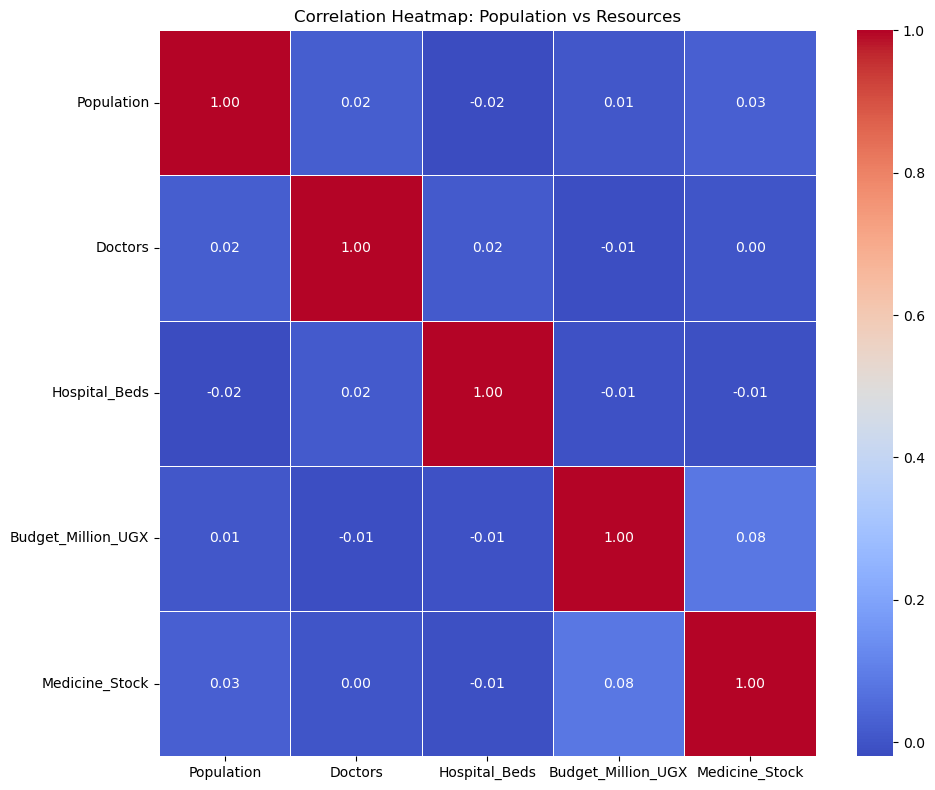

In [15]:
plt.figure(figsize=(10, 8))
corr_matrix = df[cols_to_impute].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap: Population vs Resources')
plt.tight_layout()
plt.show()

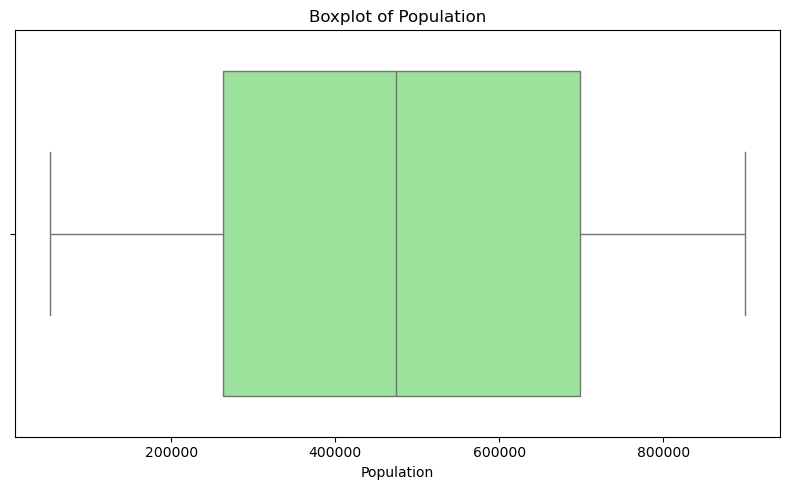

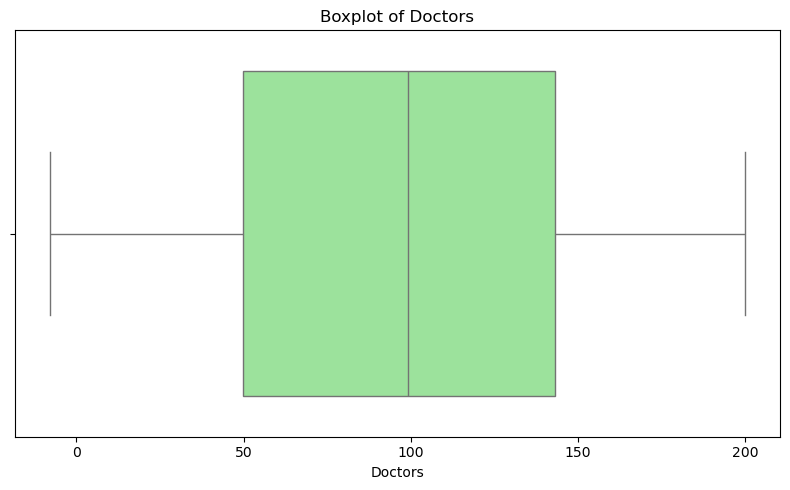

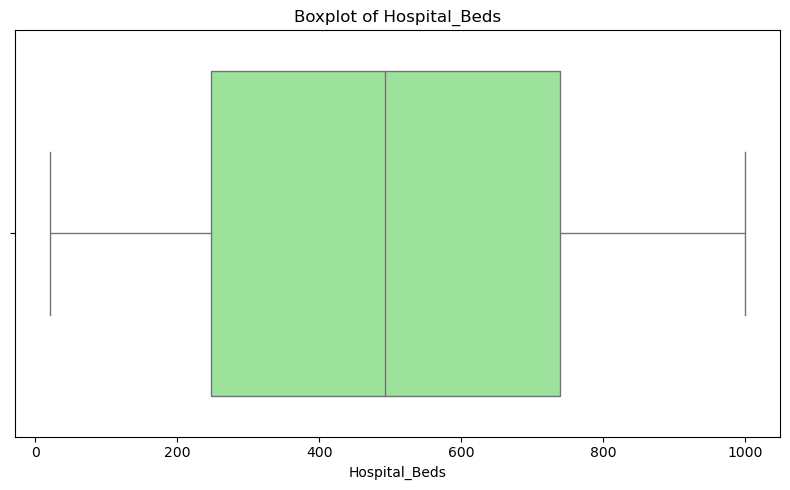

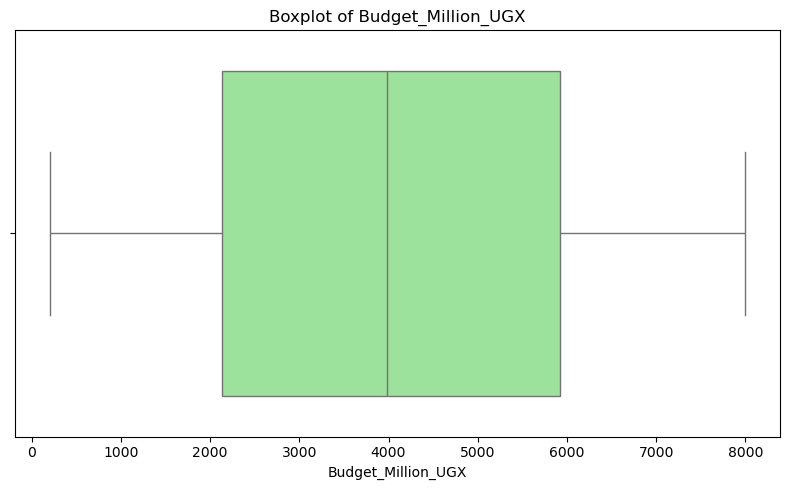

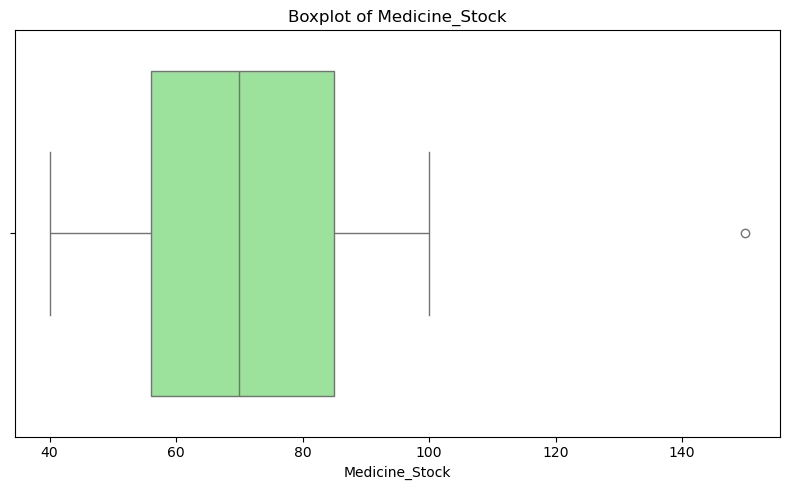

In [16]:
#outlier detection using boxplots for doctors, hospital beds, budget, and medicine stock
for col in cols_to_impute:
    plt.figure(figsize=(8, 5))
    sns.boxplot(x=df[col], color='lightgreen')
    plt.title(f'Boxplot of {col}')
    plt.xlabel(col)
    plt.tight_layout()
    plt.show()

In [17]:

#Sorting - find the districts with the highest disease cases

df.sort_values("Disease_Cases", ascending=False).head(10)

,District,Region,Population,Health_Facilities,Doctors,Nurses,Hospital_Beds,Disease_Cases,Medicine_Stock,Emergency_Visits,Budget_Million_UGX,Resource_Need_Level
668,Mbarara,Eastern,425333.0,44,121.0,388,108.0,49960,63.0,3497,6966.0,High
715,Arua,Eastern,284017.0,52,67.0,443,136.0,49937,54.0,235,1137.0,High
1315,Mbale,Western,284929.0,51,13.0,478,141.0,49922,56.0,6425,616.0,High
153,Mbarara,Northern,263029.0,19,13.0,55,992.0,49898,80.0,1533,6958.0,High
1096,Wakiso,Eastern,187472.0,18,107.0,538,609.0,49885,57.0,6608,6232.0,High
800,Lira,Western,780563.0,53,26.0,30,609.0,49802,41.0,9753,4666.0,High
880,Jinja,Central,660253.0,50,94.0,416,632.0,49754,47.0,5638,2905.0,High
565,Wakiso,Eastern,767288.0,9,81.0,90,892.0,49696,82.0,5683,3782.0,High
212,Masaka,Central,616211.0,75,129.0,410,225.0,49664,86.0,3934,2735.0,High
1054,Kampala,Central,521686.0,22,73.0,151,372.0,49605,87.0,5268,6360.0,High


In [18]:

# Lowest medicine stock - could signal districts at risk of shortages
df.sort_values("Medicine_Stock").head(10)

,District,Region,Population,Health_Facilities,Doctors,Nurses,Hospital_Beds,Disease_Cases,Medicine_Stock,Emergency_Visits,Budget_Million_UGX,Resource_Need_Level
1495,Kampala,Northern,83809.0,59,186.0,504,621.0,32601,40.0,1298,3407.0,High
82,Kampala,Northern,83809.0,59,186.0,504,621.0,32601,40.0,1298,3407.0,High
1300,Arua,Western,233670.0,14,150.0,463,329.0,21471,40.0,8926,1165.0,Medium
1311,Jinja,Eastern,861075.0,68,139.0,582,597.0,26746,40.0,9072,4142.0,Medium
798,Mbarara,Central,631870.0,47,103.0,256,654.0,21401,40.0,255,3842.0,Medium
347,Jinja,Northern,898526.0,35,94.0,174,158.0,13958,40.0,7524,3517.0,Medium
353,Kabale,Central,133160.0,14,152.0,369,756.0,9456,40.0,3183,2417.0,Low
806,Arua,Eastern,347137.0,76,92.0,281,694.0,48257,40.0,3741,2904.0,High
433,Gulu,Northern,257828.0,33,180.0,359,745.0,4883,40.0,7959,509.0,Low
614,Kampala,Eastern,605968.0,9,117.0,580,829.0,38228,40.0,7498,3796.0,High


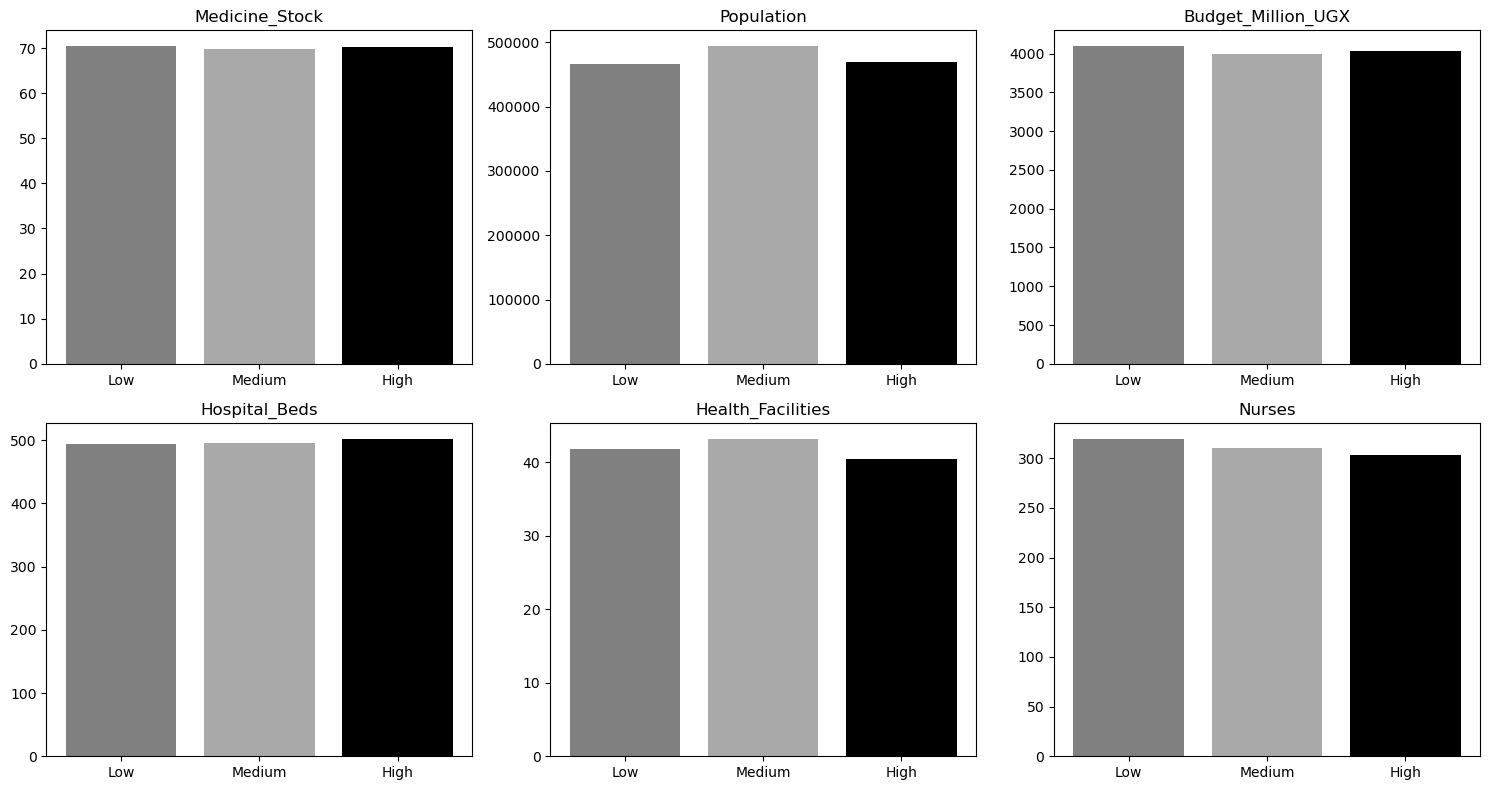

In [19]:
# The 6 "noise" columns we're checking
noise_cols = ['Medicine_Stock', 'Population', 'Budget_Million_UGX',
              'Hospital_Beds', 'Health_Facilities', 'Nurses']

# Create a grid of 6 small charts (2 rows, 3 columns)
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()  # turns the 2x3 grid into a simple list of 6 slots

# Loop through each noisy column and draw its own bar chart
for i, col in enumerate(noise_cols):
    avg_by_need = df.groupby('Resource_Need_Level')[col].mean()
    avg_by_need = avg_by_need.reindex(['Low', 'Medium', 'High'])
    
    axes[i].bar(avg_by_need.index, avg_by_need.values, color=['gray', 'darkgray', 'black'])
    axes[i].set_title(col)

plt.tight_layout()  # stops the charts from overlapping each other
plt.show()

Resource_Need_Level
Low       108.019589
Medium    109.367704
High       87.256745
Name: Doctors, dtype: float64


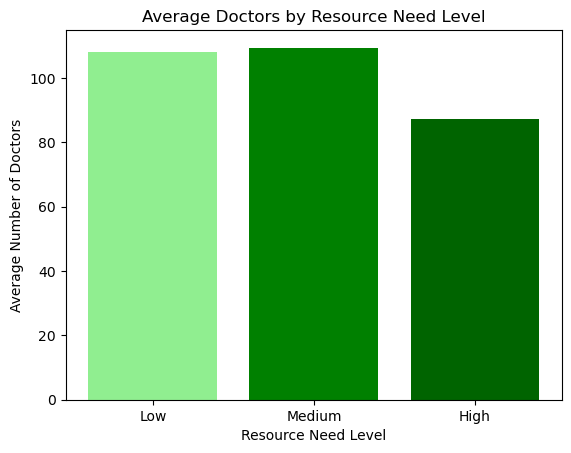

In [20]:
#  Average Doctors per need level
avg_doctors = df.groupby('Resource_Need_Level')['Doctors'].mean()

# Put it in logical order (Low, Medium, High)
avg_doctors = avg_doctors.reindex(['Low', 'Medium', 'High'])

print(avg_doctors)

# Plot it
plt.bar(avg_doctors.index, avg_doctors.values, color=['lightgreen', 'green', 'darkgreen'])
plt.title('Average Doctors by Resource Need Level')
plt.xlabel('Resource Need Level')
plt.ylabel('Average Number of Doctors')
plt.show()

Resource_Need_Level
Low        6465.952978
Medium    21032.787938
High      37511.029985
Name: Disease_Cases, dtype: float64


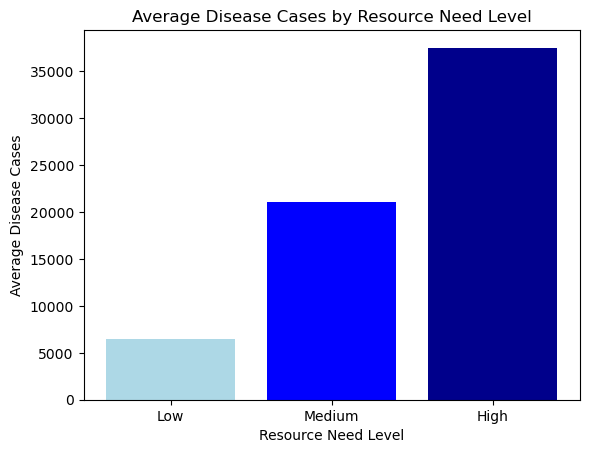

In [21]:
#  Calculate the average Disease_Cases for each need level
avg_disease = df.groupby('Resource_Need_Level')['Disease_Cases'].mean()

#  Reorder so it goes Low -> Medium -> High (otherwise it's alphabetical)
avg_disease = avg_disease.reindex(['Low', 'Medium', 'High'])

print(avg_disease)

# Step 3: Plot it as a bar chart
plt.bar(avg_disease.index, avg_disease.values, color=['lightblue', 'blue', 'darkblue'])
plt.title('Average Disease Cases by Resource Need Level')
plt.xlabel('Resource Need Level')
plt.ylabel('Average Disease Cases')
plt.show()

In [22]:
# 1. Fix Impossible Values: Negative Doctors
print(f"Number of rows with negative doctors BEFORE: {len(df[df['Doctors'] < 0])}")

# We will replace any number of doctors less than 0 with the median (middle) value
median_doctors = df['Doctors'].median()
df.loc[df['Doctors'] < 0, 'Doctors'] = median_doctors

print(f"Number of rows with negative doctors AFTER: {len(df[df['Doctors'] < 0])}")

# 2. Fix the Extreme Outlier: Log Transformation (Keeping Original!)
print("\nCreating new Log-Transformed Medicine_Stock column...")

# Create the new column with the logged values
df['Medicine_Stock_Log'] = np.log1p(df['Medicine_Stock'])


print("Medicine_Stock_Log successfully created! Original column kept.")

# 3. Final sanity check on our fixes
# Let's look at the original and the logged version side-by-side
display(df[['Doctors', 'Medicine_Stock', 'Medicine_Stock_Log']].describe())

Number of rows with negative doctors BEFORE: 1
Number of rows with negative doctors AFTER: 0

Creating new Log-Transformed Medicine_Stock column...
Medicine_Stock_Log successfully created! Original column kept.


,Doctors,Medicine_Stock,Medicine_Stock_Log
count,1500.000000,1500.000000,1500.000000
mean,99.320415,70.130087,4.233151
std,55.947191,17.333784,0.254684
min,5.000000,40.000000,3.713572
25%,50.000000,56.000000,4.043051
50%,99.186749,70.000000,4.262680
75%,143.250000,85.000000,4.454347
max,200.000000,150.000000,5.017280


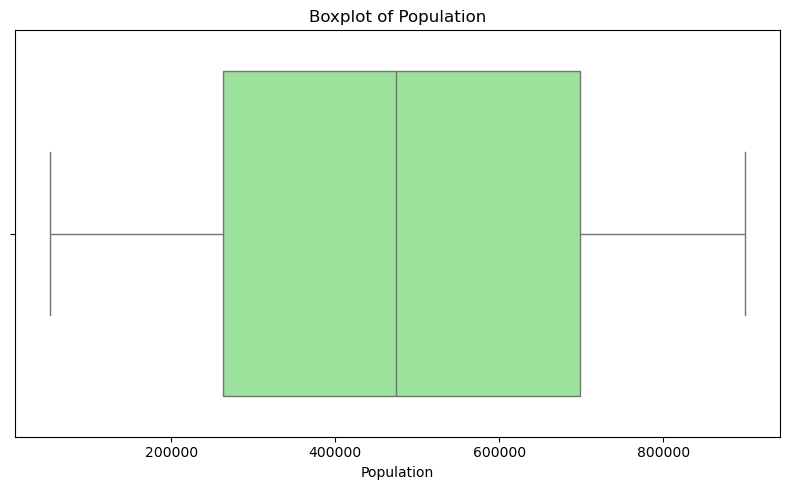

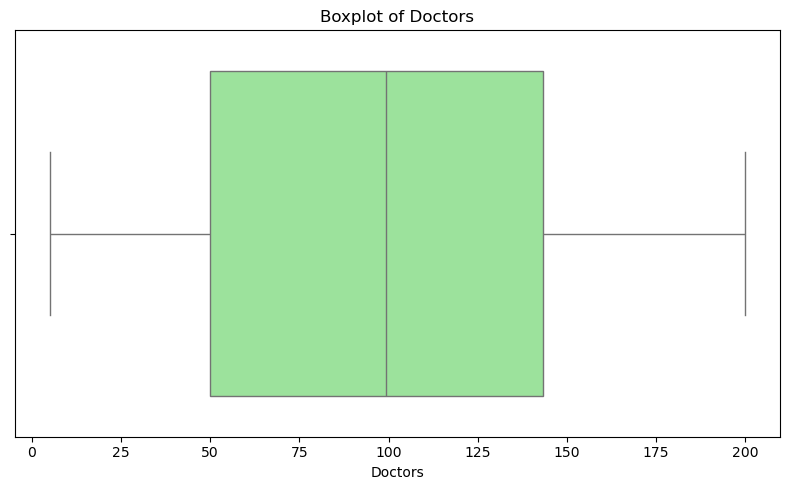

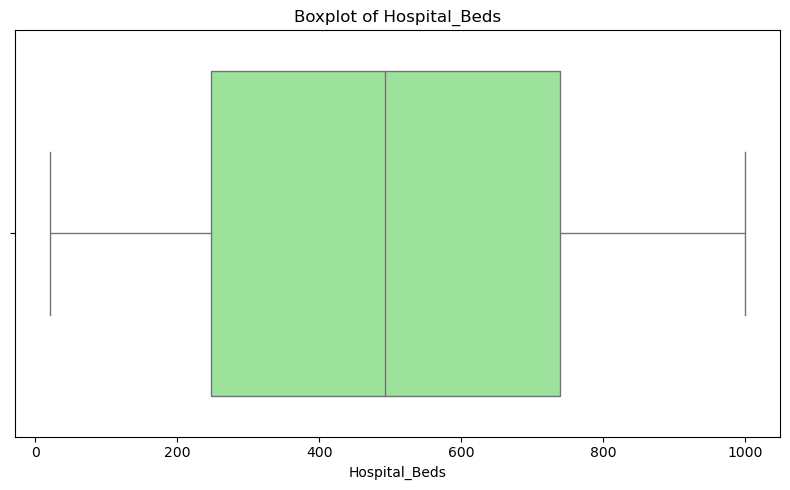

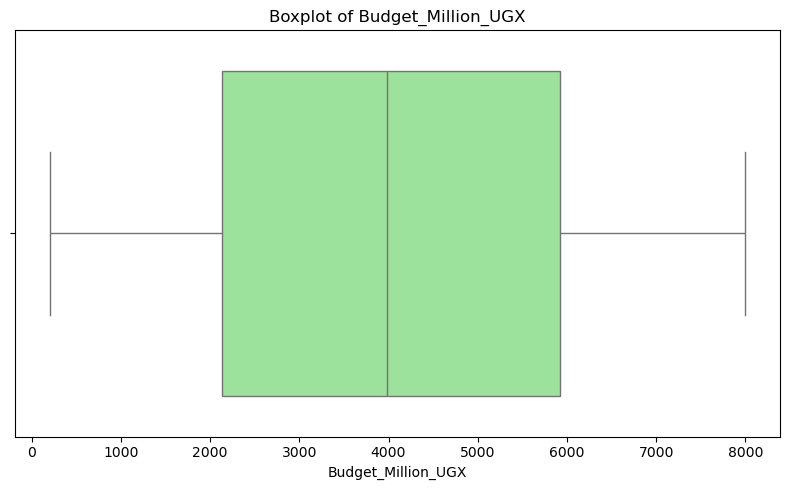

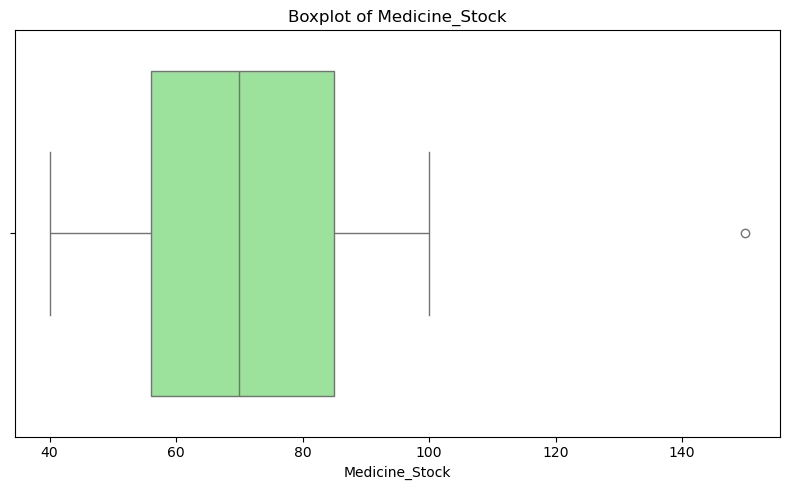

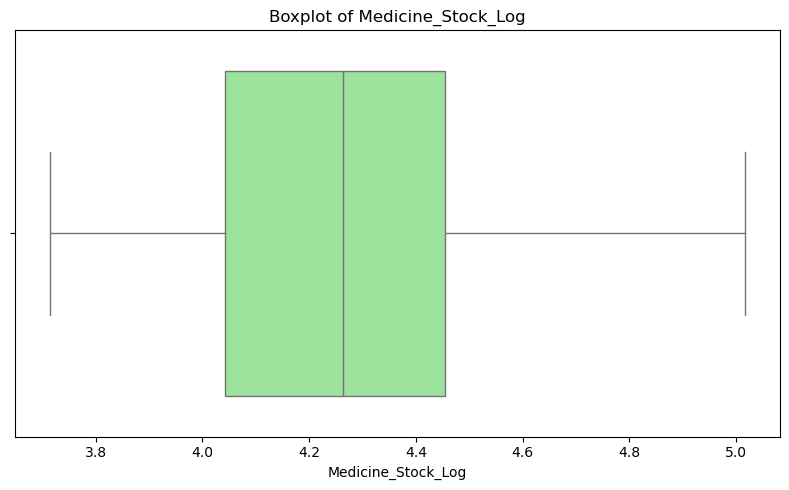

['Population', 'Doctors', 'Hospital_Beds', 'Budget_Million_UGX', 'Medicine_Stock', 'Medicine_Stock_Log']


In [23]:

cols_to_impute.append('Medicine_Stock_Log')
for col in cols_to_impute:
    plt.figure(figsize=(8, 5))
    sns.boxplot(x=df[col], color='lightgreen')
    plt.title(f'Boxplot of {col}')
    plt.xlabel(col)
    plt.tight_layout()
    plt.show()

print(cols_to_impute)


In [26]:
# ==========================================
# PART 1: CHECKING FOR NEGATIVE VALUES
# ==========================================
print("--- Checking all numeric columns for negative values ---")

# Automatically select only the columns that are numbers (integers or floats)
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

# Check if values are less than 0, then sum them up per column
negative_counts = (df[numeric_cols] < 0).sum()

# Filter to only show columns that have more than 0 negative values
negatives_found = negative_counts[negative_counts > 0]

if len(negatives_found) == 0:
    print(" No negative values found in any numeric column.")
else:
    print("Warning! Negative values found in:")
    display(negatives_found)

print("\n" + "="*42 + "\n")

# ==========================================
# PART 2: ENCODING (KEEPING ORIGINALS)
# ==========================================
print("--- Encoding Features ---")

encoder=LabelEncoder()
df['Resource_Need_Level_num']= encoder.fit_transform(df['Resource_Need_Level'])

# 1. Target Encoding: Create a BRAND NEW column instead of overwriting
#need_mapping = {'Low': 0, 'Medium': 1, 'High': 2}
#df['Target_Encoded'] = df['Resource_Need_Level'].map(need_mapping)

# 2. One-Hot Encoding: Generate dummies separately
# Notice we are only passing the two text columns to get_dummies
dummies = pd.get_dummies(df[['Region', 'District']], drop_first=True)

# Glue (concatenate) the original dataframe and the new dummy columns side-by-side (axis=1)
df_encoded = pd.concat([df, dummies], axis=1)

print("Original columns kept! Features encoded successfully.")
print(f"New Dataset Shape: {df_encoded.shape}")

# Let's look at the columns to prove the original and new ones are both there
display(df_encoded[['District', 'Region', 'Resource_Need_Level', 'Resource_Need_Level_num']].head())



--- Checking all numeric columns for negative values ---
 No negative values found in any numeric column.


--- Encoding Features ---
Original columns kept! Features encoded successfully.
New Dataset Shape: (1500, 26)


,District,Region,Resource_Need_Level,Resource_Need_Level_num
0,Jinja,Northern,Medium,2
1,Masaka,Northern,Medium,2
2,Kampala,Central,Medium,2
3,Gulu,Western,Medium,2
4,Kabale,Northern,Low,1


In [27]:
#feature selection
selected_features = ['Health_Facilities', 'Doctors', 'Population', 'Nurses', 'Hospital_Beds', 'Disease_Cases', 'Medicine_Stock_Log']
x = df[selected_features]
y = df['Resource_Need_Level_num']

#train, test split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size= 0.25, random_state=42)

# Create the scaler
scaler = StandardScaler()

# Fit on training data and transform it
x_train = scaler.fit_transform(x_train)

# Transform the test data using the same scaler
x_test = scaler.transform(x_test)


In [28]:
#random forest classifier 
# we aim at classifying under resource need levels

model = RandomForestClassifier(
    n_estimators=100,        # Number of trees in the forest
    max_depth=10,            # How deep each tree can grow
    min_samples_split=5,     # Minimum samples required to split a node
    min_samples_leaf=2,      # Minimum samples required in a leaf node
    random_state=42)

print("Train random forest classifier")

model.fit(x_train, y_train)

print("Model testing....")
y_pred =model.predict(x_test)

Train random forest classifier
Model testing....



 Model Accuracy on Test Set: 99.20%

 Detailed Classification Report:
              precision    recall  f1-score   support

     Level_0       1.00      1.00      1.00       174
     Level_1       0.96      1.00      0.98        76
     Level_2       1.00      0.98      0.99       125

    accuracy                           0.99       375
   macro avg       0.99      0.99      0.99       375
weighted avg       0.99      0.99      0.99       375


 Confusion Matrix (Rows=Actual, Columns=Predicted):
[[174   0   0]
 [  0  76   0]
 [  0   3 122]]


C:\Users\olayo\AppData\Local\Temp\ipykernel_43428\2406128092.py:25: UserWarning: Glyph 127795 (\N{DECIDUOUS TREE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\olayo\anaconda3\envs\hram\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127795 (\N{DECIDUOUS TREE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


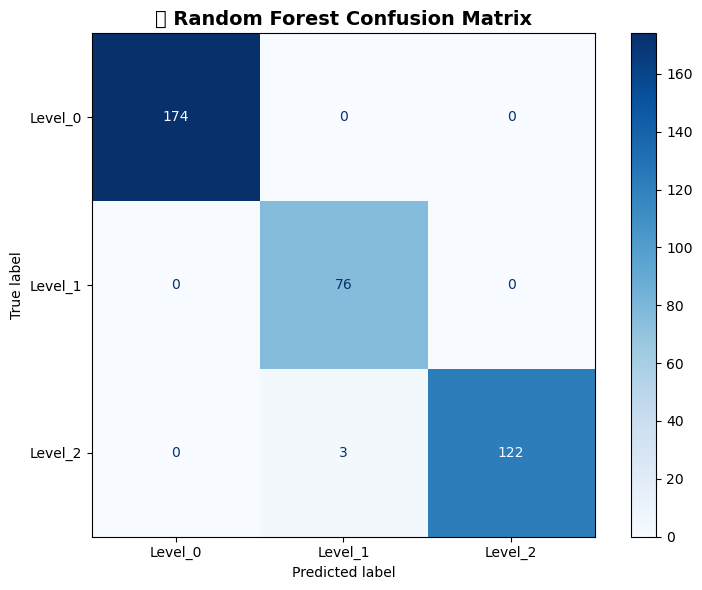

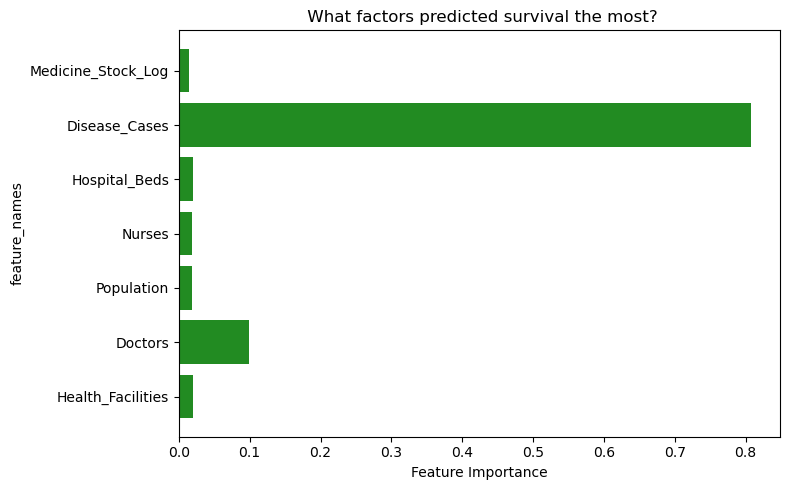


 Feature Importance Scores:
   - Health_Facilities: 2.06%
   - Doctors: 9.95%
   - Population: 1.89%
   - Nurses: 1.88%
   - Hospital_Beds: 2.00%
   - Disease_Cases: 80.81%
   - Medicine_Stock_Log: 1.41%


In [29]:
#evaluation
# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"\n Model Accuracy on Test Set: {accuracy:.2%}")

unique_classes = sorted(y.unique())
class_names = [f'Level_{cls}' for cls in unique_classes]  # Example: Level_1, Level_2, Level_3

# Show detailed statistics
print("\n Detailed Classification Report:")
print(classification_report(y_test, y_pred, target_names=class_names))

# Show the Confusion Matrix (how many correct vs wrong)
print("\n Confusion Matrix (Rows=Actual, Columns=Predicted):")
print(confusion_matrix(y_test, y_pred))


# Confusion Matrix
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_estimator(model, x_test, y_test, 
                                      display_labels=class_names,
                                      cmap='Blues',
                                      ax=ax)
ax.set_title('🌳 Random Forest Confusion Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 6. THE BEST PART: FEATURE IMPORTANCE!
# ------------------------------------------------------------
# This tells you which columns the model relied on the most.

importances = model.feature_importances_
feature_names = selected_features

# Create a nice bar chart
plt.figure(figsize=(8, 5))
plt.barh(feature_names, importances, color='forestgreen')
plt.xlabel('Feature Importance')
plt.ylabel('feature_names')
plt.title(' What factors predicted survival the most?')
plt.tight_layout()
plt.show()

# Print the exact numbers
print("\n Feature Importance Scores:")
for name, score in zip(feature_names, importances):
    print(f"   - {name}: {score:.2%}")



Training the Random Forest Regressor...

 REGRESSION MODEL EVALUATION
R-Squared (R²): 0.0129 (Closer to 1.0 is better)
Mean Absolute Error (MAE): 1855.01 Million UGX


C:\Users\olayo\AppData\Local\Temp\ipykernel_43428\1047226489.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df.head(10), x='Importance', y='Feature', palette='viridis')


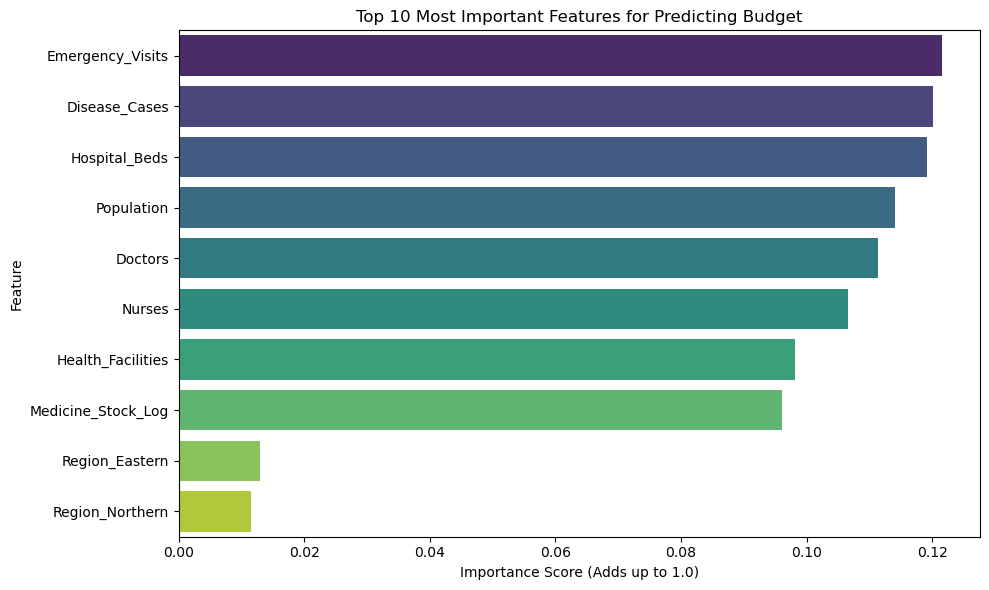

In [30]:
# 1. Define the NEW Target (y) and Features (X) for Regression
y_reg = df_encoded['Budget_Million_UGX']

# Drop text columns, the old classification targets, AND the new budget target
columns_to_drop = ['District', 'Region', 'Resource_Need_Level', 'Resource_Need_Level_num', 'Budget_Million_UGX']
X_reg = df_encoded.drop(columns=columns_to_drop)

# Prevent Multicollinearity: Drop original Medicine_Stock if Log is present
if 'Medicine_Stock' in X_reg.columns and 'Medicine_Stock_Log' in X_reg.columns:
    X_reg = X_reg.drop(columns=['Medicine_Stock'])

# 2. Train/Test Split (Notice we don't use 'stratify' for regression!)
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

# 3. Initialize and Train the Regression Model
print("Training the Random Forest Regressor...")
reg_model = RandomForestRegressor(random_state=42)
reg_model.fit(X_train_r, y_train_r)

# 4. Evaluate the Model
y_pred_r = reg_model.predict(X_test_r)
mae = mean_absolute_error(y_test_r, y_pred_r)
r2 = r2_score(y_test_r, y_pred_r)

print("\n" + "="*30)
print(" REGRESSION MODEL EVALUATION")
print("="*30)
print(f"R-Squared (R²): {r2:.4f} (Closer to 1.0 is better)")
print(f"Mean Absolute Error (MAE): {mae:.2f} Million UGX")
print("="*30)

# 5. Extract and Plot FEATURE IMPORTANCE
# This answers your question: "What is the most useful resource?"
importances = reg_model.feature_importances_
feature_names = X_reg.columns

# Put it in a DataFrame and sort it
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Plotting
plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df.head(10), x='Importance', y='Feature', palette='viridis')
plt.title('Top 10 Most Important Features for Predicting Budget')
plt.xlabel('Importance Score (Adds up to 1.0)')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()